In [51]:
!pip -q install datasets

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from datasets import load_dataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [52]:
dataset = load_dataset("ylecun/mnist")
print(dataset)


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})


In [53]:
def images_to_tensor(split):
    images = []
    for image in dataset[split]["image"]:
        arr = np.array(image, dtype=np.float32)
        arr = arr / 255.0          # normalize
        arr = arr.flatten()        # 28x28 -> 784
        images.append(arr)
    return torch.tensor(np.array(images), dtype=torch.float32)

X_train = images_to_tensor("train")
X_test  = images_to_tensor("test")

y_train = torch.tensor(dataset["train"]["label"], dtype=torch.long)
y_test  = torch.tensor(dataset["test"]["label"], dtype=torch.long)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=128, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=128, shuffle=False)


X_train shape: torch.Size([60000, 784])
X_test shape: torch.Size([10000, 784])


In [54]:
sample_input = X_train[0].unsqueeze(0)
W_demo = torch.randn(10, 784)
b_demo = torch.randn(10)

manual_output = sample_input @ W_demo.T + b_demo
print("Input shape:", sample_input.shape)
print("Weight shape:", W_demo.shape)
print("Manual tensor-multiplication output shape:", manual_output.shape)
print("Manual output (raw values, this is exactly what nn.Linear computes):")
print(manual_output)

Input shape: torch.Size([1, 784])
Weight shape: torch.Size([10, 784])
Manual tensor-multiplication output shape: torch.Size([1, 10])
Manual output (raw values, this is exactly what nn.Linear computes):
tensor([[ -3.9305,  -6.1857,  -9.9905, -14.1116,  -6.6896,   7.4194,   6.8563,
          -6.7490,  10.1361,   5.6534]])


In [55]:
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(784, 128)
        self.layer2 = nn.Linear(128, 64)
        self.output_layer = nn.Linear(64, 10)   # 10 raw logits, one per digit
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output_layer(x)   # RAW LOGITS — no activation applied here
        return x

model = DigitClassifier()
print(model)

DigitClassifier(
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (output_layer): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


In [56]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        logits = model(images)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {running_loss/len(train_loader):.4f} "
          f"Train Accuracy: {100*correct/total:.2f}%")

Epoch [1/5] Loss: 0.4162 Train Accuracy: 88.89%
Epoch [2/5] Loss: 0.1716 Train Accuracy: 94.98%
Epoch [3/5] Loss: 0.1206 Train Accuracy: 96.38%
Epoch [4/5] Loss: 0.0920 Train Accuracy: 97.20%
Epoch [5/5] Loss: 0.0731 Train Accuracy: 97.77%


In [57]:
model.eval()
with torch.no_grad():
    test_logits = model(X_test)     # RAW logits, before any activation

print("Logits BEFORE activation — sample (first test image):")
print(test_logits[0])
print("\nLogits shape:", test_logits.shape)

Logits BEFORE activation — sample (first test image):
tensor([ -2.3236,  -4.2537,   1.2549,   1.8812, -11.2751,  -4.1376, -18.5479,
          8.3404,  -2.6451,  -0.9996])

Logits shape: torch.Size([10000, 10])


In [58]:
with torch.no_grad():
    softmax_probs = torch.softmax(test_logits, dim=1)

print("Logits AFTER softmax — sample (first test image):")
print(softmax_probs[0])
print("Sum of probabilities (should be ~1):", softmax_probs[0].sum().item())

softmax_preds = torch.argmax(softmax_probs, dim=1)
softmax_accuracy = (softmax_preds == y_test).float().mean().item() * 100

print(f"\nSoftmax-based Accuracy: {softmax_accuracy:.2f}%")

Logits AFTER softmax — sample (first test image):
tensor([2.3313e-05, 3.3835e-06, 8.3506e-04, 1.5621e-03, 3.0199e-09, 3.7998e-06,
        2.0964e-12, 9.9747e-01, 1.6902e-05, 8.7618e-05])
Sum of probabilities (should be ~1): 1.0

Softmax-based Accuracy: 97.33%


In [59]:
with torch.no_grad():
    sigmoid_probs = torch.sigmoid(test_logits)

print("Logits AFTER sigmoid — sample (first test image):")
print(sigmoid_probs[0])
print("Sum of probabilities (NOT forced to 1):", sigmoid_probs[0].sum().item())

sigmoid_preds = torch.argmax(sigmoid_probs, dim=1)
sigmoid_accuracy = (sigmoid_preds == y_test).float().mean().item() * 100

print(f"\nSigmoid-based Accuracy: {sigmoid_accuracy:.2f}%")

Logits AFTER sigmoid — sample (first test image):
tensor([8.9190e-02, 1.4013e-02, 7.7815e-01, 8.6775e-01, 1.2685e-05, 1.5710e-02,
        8.8058e-09, 9.9976e-01, 6.6289e-02, 2.6902e-01])
Sum of probabilities (NOT forced to 1): 3.0998916625976562

Sigmoid-based Accuracy: 97.33%


In [60]:
print(f"{'Metric':<25}{'Softmax':>12}{'Sigmoid':>12}")
print("-" * 49)
print(f"{'Accuracy (%)':<25}{softmax_accuracy:>12.2f}{sigmoid_accuracy:>12.2f}")

agreement = (softmax_preds == sigmoid_preds).float().mean().item() * 100
print(f"\nPredictions matching between Softmax and Sigmoid: {agreement:.2f}%")
print("\n(This will usually be ~100% — both are monotonic functions of the")
print("logits, so argmax picks the same class either way. The difference")
print("is only in the probability VALUES, not the final predicted class.)")

print("\nSample-by-sample comparison (first 10 test images):")
print(f"{'True':>6}{'Softmax Pred':>15}{'Sigmoid Pred':>15}")
for i in range(10):
    print(f"{y_test[i].item():>6}{softmax_preds[i].item():>15}{sigmoid_preds[i].item():>15}")



Metric                        Softmax     Sigmoid
-------------------------------------------------
Accuracy (%)                    97.33       97.33

Predictions matching between Softmax and Sigmoid: 100.00%

(This will usually be ~100% — both are monotonic functions of the
logits, so argmax picks the same class either way. The difference
is only in the probability VALUES, not the final predicted class.)

Sample-by-sample comparison (first 10 test images):
  True   Softmax Pred   Sigmoid Pred
     7              7              7
     2              2              2
     1              1              1
     0              0              0
     4              4              4
     1              1              1
     4              4              4
     9              9              9
     5              5              5
     9              9              9


Confusion Matrix (Softmax predictions):
[[ 966    0    1    2    0    5    3    1    2    0]
 [   0 1125    4    0    0    1    2    0    3    0]
 [   3    1 1014    3    2    1    1    4    3    0]
 [   0    0    6  988    1    4    0    6    5    0]
 [   0    0    2    0  965    1    5    0    0    9]
 [   3    0    0    9    2  873    1    0    2    2]
 [   5    3    2    1    8    7  930    0    2    0]
 [   1    8   10    4    1    1    0  995    2    6]
 [   4    3    7    9    4   10    3    3  928    3]
 [   4    7    0    6   22    9    0    6    6  949]]


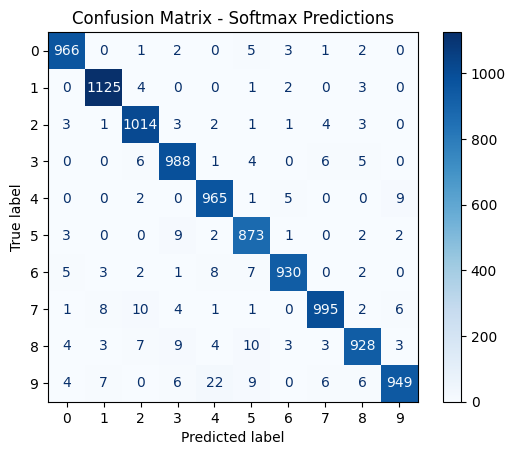

In [61]:
cm_softmax = confusion_matrix(y_test.numpy(), softmax_preds.numpy())

print("Confusion Matrix (Softmax predictions):")
print(cm_softmax)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_softmax, display_labels=range(10))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Softmax Predictions")
plt.show()